In [63]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = os.path.join(parent_dir, 'dfs')


In [64]:
# Load device, cshq, and sleep diary data file:
df_3nights = pd.read_csv(os.path.join(data_path, 'merged_3nights.csv'))
df_cshq = pd.read_csv(os.path.join(data_path, 'df_cshq_clean.csv'))

# Load subject demographics:
df_demographics = pd.read_csv(os.path.join(data_path, 'SSP_participants.csv'))

print(f"Number of recordings in df3_nights: {len(df_3nights)}")
print(f"Number of subjects in df_cshq: {len(df_cshq)}")
print(f"Number of subjects in df_demographics: {len(df_demographics)}")

Number of recordings in df3_nights: 1151
Number of subjects in df_cshq: 200
Number of subjects in df_demographics: 200


### Preprocess the 3_nights data

In [65]:
# Compute the average per subject of selected sleep measures:

df_3nights_bysub = df_3nights[['SPID', 'SOL',
                               'TST_dreem', 'TST_embrace', 'TST_withings', 'TST_diary', 
                               'WASO_dreem', 'WASO_embrace', 'WASO_withings', 'WASO_diary']].groupby('SPID').mean()

# Replace SOL_dreem values larger than 120 with Nan:
df_3nights_bysub['SOL_dreem'] = df_3nights_bysub['SOL'].apply(lambda x: np.nan if x>120 else x)

print(len(df_3nights_bysub))
print(f"Number of nights after filtering SOL periods longer than 2h: {df_3nights_bysub['SOL_dreem'].notna().sum()}")

136
Number of nights after filtering SOL periods longer than 2h: 135


In [66]:
# Merge demographic details and cshq into the dataframe:
df_3nights_demog = df_3nights_bysub.merge(df_demographics[['SPID', 'family_SPID', 'sex', 'asd', 
                                                           'age_months', 'age_years']], on='SPID', how='inner')

# Merge cshq data:
df_3nights_demog = df_3nights_demog.merge(df_cshq[['SPID', 'TST', 'WASO']], on='SPID', how='inner')

# Rename TST and WASO columns to TST_cshq and WASO_cshq:
df_3nights_demog = df_3nights_demog.rename(columns={'TST': 'TST_cshq', 'WASO': 'WASO_cshq'})


print(f"Number of subjects in df_3nights_demog: {len(df_3nights_demog)}")

Number of subjects in df_3nights_demog: 136


In [67]:
# Count number of ASD and Sibs:
asd_count = df_3nights_demog['asd'].sum()
sib_count = len(df_3nights_demog) - asd_count

# Compute the mean SOL_dreem for ASD and Sibs:
asd_SOL = df_3nights_demog[df_3nights_demog['asd']==1]['SOL_dreem'].mean()
sib_SOL = df_3nights_demog[df_3nights_demog['asd']==0]['SOL_dreem'].mean()

print(f"Number of ASD subjects: {asd_count}")
print(f"Number of Sibs subjects: {sib_count}")
print(f"Mean SOL_dreem for ASD subjects: {asd_SOL}")
print(f"Mean SOL_dreem for Sibs subjects: {sib_SOL}")

Number of ASD subjects: 69
Number of Sibs subjects: 67
Mean SOL_dreem for ASD subjects: 36.54594688118127
Mean SOL_dreem for Sibs subjects: 28.82235247422414


### Plot Sleep measures comparison across groups 

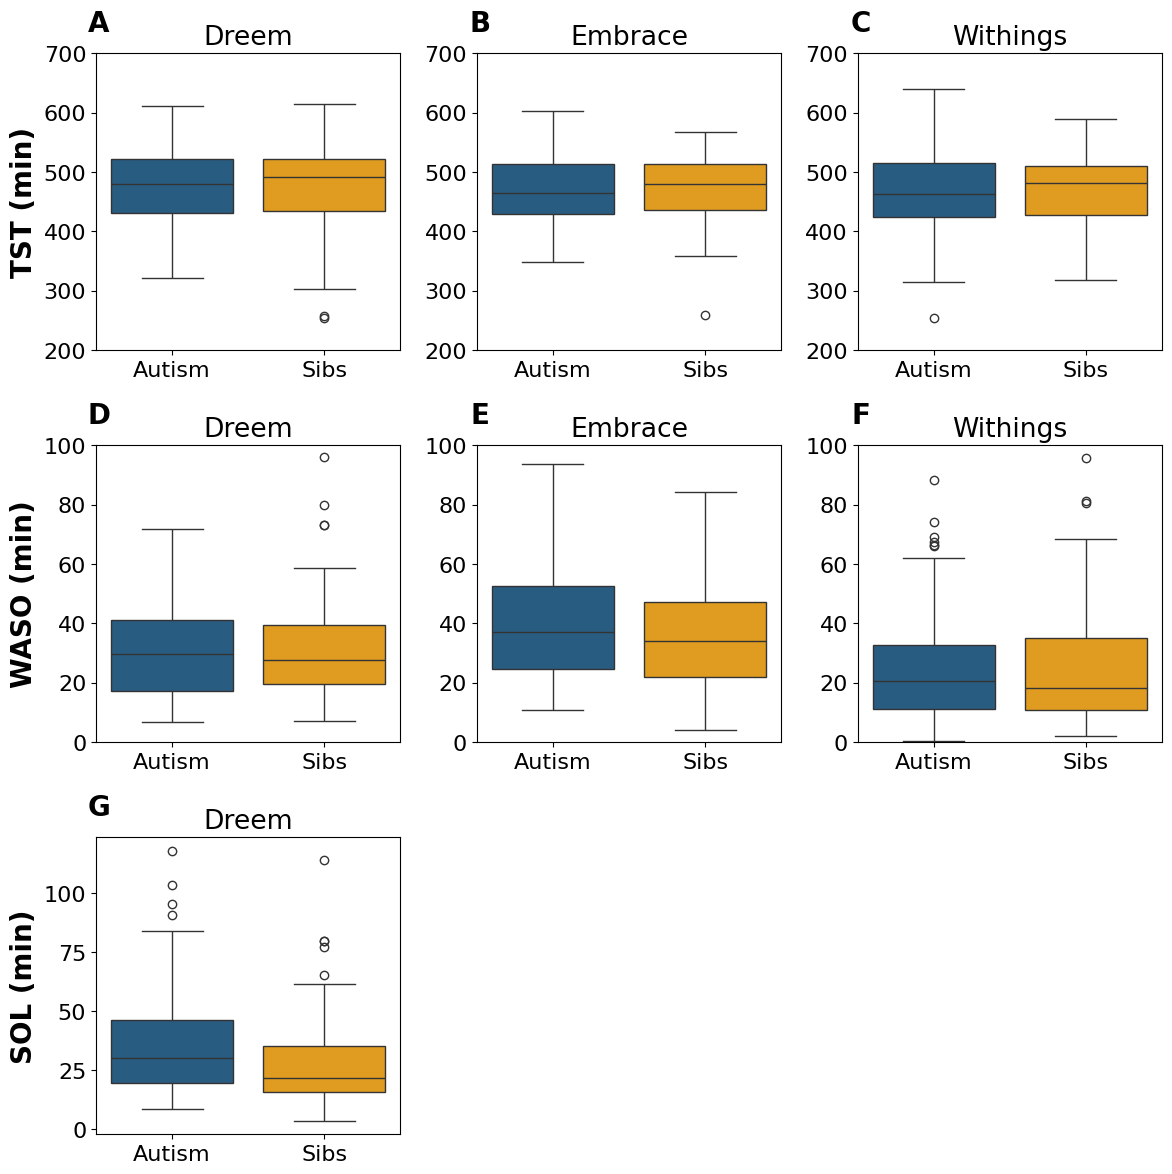

In [68]:
# List of SO FA TST and WASO columns
tst_columns = ['TST_dreem', 'TST_embrace', 'TST_withings']
waso_columns = ['WASO_dreem', 'WASO_embrace', 'WASO_withings']
sol_columns = ['SOL_dreem']

# Combine all columns to plot
columns_to_plot = tst_columns + waso_columns + sol_columns

# Organize the data by group:
df_3nights_demog['Group'] = df_3nights_demog.apply(lambda row: 'Autism' if row['asd'] else 'Sibs', axis=1)

# Order in which to plot the groups:
group_order = ['Autism', 'Sibs']

# Create a figure with 9 subplots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharey=False)

# Define a color palette for the groups
hue_colors = {'Autism': '#19609080', 'Sibs': '#FFA500'}

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Set global font size for the plot
plt.rcParams.update({'font.size': 16})

# Loop through the columns and create boxplots
for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    sns.boxplot(data=df_3nights_demog, x='Group', y=column, ax=ax, order=group_order, hue='Group', dodge=False, palette=hue_colors)
    # Isolate the metric name from the column name:
    metric = column.split('_')[0].upper()
    if metric == 'TST':
        ax.set_ylim(200, 700)
    elif metric == 'WASO':
        ax.set_ylim(0, 100)

    # Isolate the metric name and device name from the column name
    metric, device = column.split('_')[0].upper(), column.split('_')[1].capitalize()

    ax.set_title(device)

    # Add capital letters in the top left corner of each panel
    panel_label = string.ascii_uppercase[i]  # Get the corresponding letter (A, B, C, etc.)
    ax.text(0.01, 1.1, panel_label, transform=ax.transAxes, fontsize=20, fontweight='bold', va='center', ha='center')

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Enlarge x and y tick markers
    ax.tick_params(axis='both', which='major', labelsize=16)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a title to each row:
axes[0].set_ylabel('TST (min)', fontsize=20, fontweight='bold')
axes[3].set_ylabel('WASO (min)', fontsize=20, fontweight='bold')
axes[6].set_ylabel('SOL (min)', fontsize=20, fontweight='bold')

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

In [69]:
# Differences in WASO across groups:
print("Difference in mean WASO_dreem between ASD and Sibs groups:")
print(df_3nights_demog[df_3nights_demog['asd']==1]['WASO_dreem'].mean() - df_3nights_demog[df_3nights_demog['asd']==0]['WASO_dreem'].mean())

print("Difference in mean WASO_embrace between ASD and Sibs groups:")
print(df_3nights_demog[df_3nights_demog['asd']==1]['WASO_embrace'].mean() - df_3nights_demog[df_3nights_demog['asd']==0]['WASO_embrace'].mean())

print("Difference in mean WASO_withings between ASD and Sibs groups:")
print(df_3nights_demog[df_3nights_demog['asd']==1]['WASO_withings'].mean() - df_3nights_demog[df_3nights_demog['asd']==0]['WASO_withings'].mean())

Difference in mean WASO_dreem between ASD and Sibs groups:
-1.9227645470520436
Difference in mean WASO_embrace between ASD and Sibs groups:
2.9175687332096913
Difference in mean WASO_withings between ASD and Sibs groups:
0.8792193924924874


### Preform a mixed model analysis:

In [97]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ── helpers 
def marginal_r2(res):
    """Nakagawa & Schielzeth (2013) marginal R²: var(fixed) / (var(fixed)+var(resid))"""
    var_fixed = np.var(res.fittedvalues)
    var_resid = res.scale
    return var_fixed / (var_fixed + var_resid)

def conditional_r2(res):
    """Conditional R²: (var(fixed)+var(random)) / total"""
    var_fixed = np.var(res.fittedvalues)
    var_resid = res.scale
    var_random = float(res.cov_re.iloc[0, 0])
    return (var_fixed + var_random) / (var_fixed + var_random + var_resid)

def f2(r2_full, r2_red):
    """Cohen's local effect size"""
    return (r2_full - r2_red) / (1.0 - r2_full)

# ── data prep
sleep_measures = [
    'TST_dreem','TST_embrace','TST_withings',
    'WASO_dreem','WASO_embrace','WASO_withings',
    'SOL_dreem'
]

df = df_3nights_demog.copy()
df.columns = df.columns.str.replace(' ', '_')
df = df.dropna(subset=sleep_measures + ['asd','sex','age_months','family_SPID'])

# ── analysis loop
all_results = []

for measure in sleep_measures:
    if measure not in df.columns:
        print(f"⚠️ {measure} not present – skipped")
        continue
    print(f"Analyzing {measure}")

    base_formula = f"{measure} ~ asd + sex + age_months"

    # full model
    full_mod = smf.mixedlm(base_formula, df, groups=df["family_SPID"])
    full_res = full_mod.fit()

    r2_full = marginal_r2(full_res)

    rand_var  = float(full_res.cov_re.iloc[0, 0])
    resid_var = full_res.scale
    icc = rand_var / (rand_var + resid_var)

    # reduced models for f²
    red_formulas = {
        'asd'       : base_formula.replace('asd', ''),
    }

    f2_vals = {}

    for key, frm in red_formulas.items():
        red_res = smf.mixedlm(frm, df, groups=df["family_SPID"]).fit()
        r2_red  = marginal_r2(red_res)
        # print(f"  {key} model R²: {r2_red:.3f}")
        f2_vals[key] = f2(r2_full, r2_red)

    print(f"  Full model R²: {r2_full:.3f}")
    print(f"  Reduced model R²: {r2_red:.3f}")

    all_results.append({
        "Measure"   : measure,
        "Between Var": rand_var,
        "Within Var" : resid_var,
        "ICC"        : icc,
        "marg_R²"    : r2_full,
        # "cond_R²"  : conditional_r2(full_res), 
        "ASD β"      : full_res.params.get('asd[T.True]',  np.nan),
        "ASD p"      : full_res.pvalues.get('asd[T.True]', np.nan),
        "ASD f²"     : f2_vals['asd'],
    })

# ── results 
results_df = pd.DataFrame(all_results)
print("\nSummary of mixed-model analysis:")
# print(results_df.round(3))
results_df

Analyzing TST_dreem
  Full model R²: 0.547
  Reduced model R²: 0.555
Analyzing TST_embrace
  Full model R²: 0.579
  Reduced model R²: 0.573
Analyzing TST_withings
  Full model R²: 0.422
  Reduced model R²: 0.430
Analyzing WASO_dreem
  Full model R²: 0.246
  Reduced model R²: 0.253
Analyzing WASO_embrace
  Full model R²: 0.105
  Reduced model R²: 0.110
Analyzing WASO_withings
  Full model R²: 0.012
  Reduced model R²: 0.010
Analyzing SOL_dreem
  Full model R²: 0.235
  Reduced model R²: 0.190

Summary of mixed-model analysis:


,Measure,Between Var,Within Var,ICC,marg_R²,ASD β,ASD p,ASD f²
0,TST_dreem,2591.302269,1937.666388,5.721617e-01,0.547226,8.153461,0.363596,-0.016942
1,TST_embrace,2064.395858,1354.244439,6.038646e-01,0.579378,8.999254,0.230467,0.014843
2,TST_withings,2045.055606,1912.944473,5.166891e-01,0.421532,4.862498,0.581121,-0.015355
3,WASO_dreem,87.420820,168.290170,3.418735e-01,0.245672,0.928402,0.714808,-0.009878
4,WASO_embrace,114.349211,363.797184,2.391510e-01,0.105232,1.442868,0.694266,-0.005147
5,WASO_withings,0.000002,404.190327,4.495869e-09,0.011767,1.611743,0.666568,0.001300
6,SOL_dreem,174.363870,333.519964,3.433145e-01,0.235262,7.566777,0.034075,0.059759
